In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


CRIM: per capita crime rate by town
ZN: proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS: proportion of non-retail business acres per town
CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise)
NOX: nitric oxides concentration (parts per 10 million)
RM: average number of rooms per dwelling
AGE: proportion of owner-occupied units built prior to 1940
DIS: weighted distances to five Boston employment centres
RAD: index of accessibility to radial highways
TAX: full-value property-tax rate per ($10,000)
PTRATIO: pupil-teacher ratio by town
B: 1000(Bk - 0.63)^2 where Bk is the proportion of [people of African American descent] by town
LSTAT: % lower status of the population
MEDV: Median value of owner-occupied homes in $1000s (target variable)

In [12]:
mydata = pd.read_csv("/content/sample_data/Boston_HousingDataSet.xls")
mydata.head()

,CRIM,ZN,INDUS,CHAS,NX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [13]:
mydata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NX       506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [15]:
mydata.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


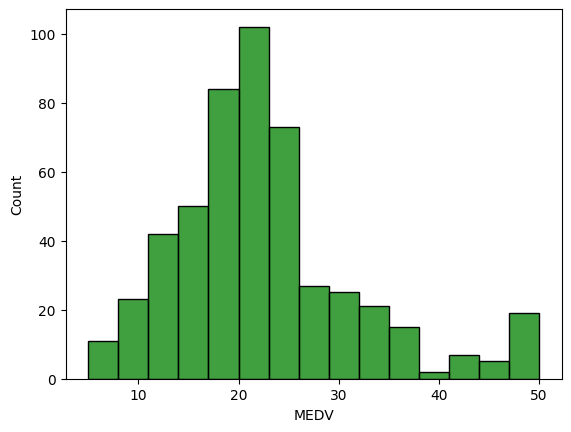

In [19]:
sns.histplot(mydata['MEDV'], bins = 15, color = 'green')
plt.show()

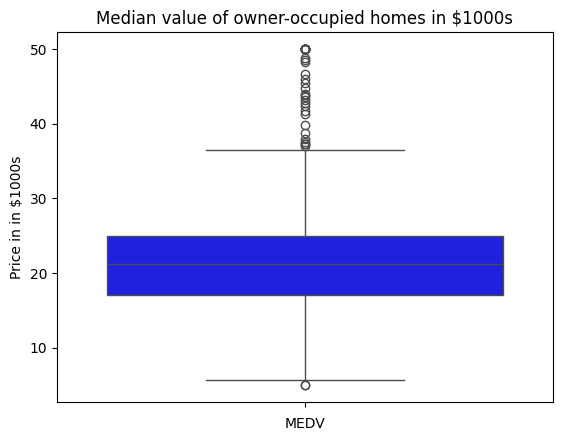

In [24]:
#Step4: Data Visualisation

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(mydata['MEDV'], color = "blue")

plt.title("Median value of owner-occupied homes in $1000s")

plt.xlabel("MEDV")

plt.ylabel("Price in in $1000s")

plt.show()

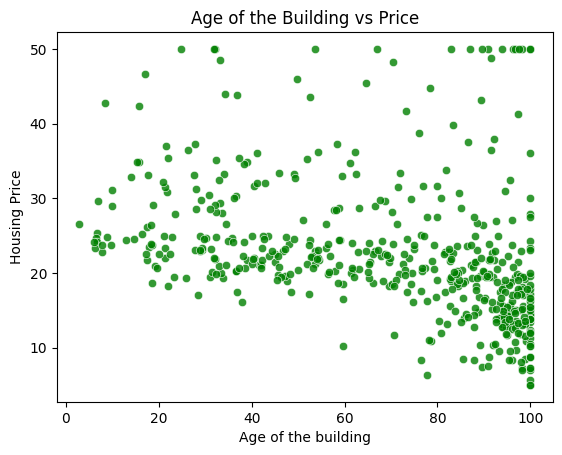

In [25]:
#SCATTER PLOTS

sns.scatterplot(x= "AGE", y = "MEDV", data = mydata, color = "green", alpha = 0.8)

plt.title("Age of the Building vs Price")

plt.xlabel("Age of the building")

plt.ylabel("Housing Price")
plt.show()

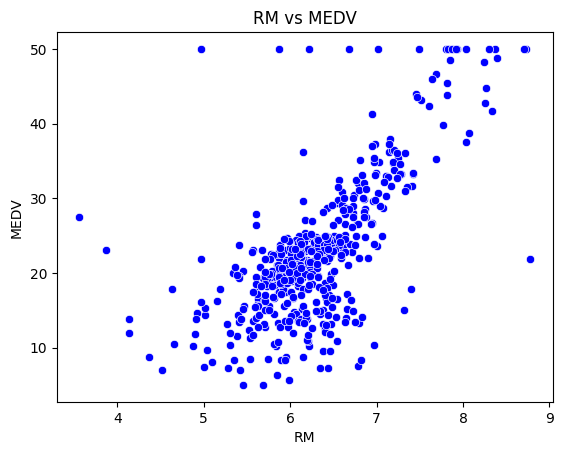

In [27]:
sns.scatterplot(x= 'RM', y= 'MEDV', data= mydata, color='blue')
plt.title('RM vs MEDV')
plt.xlabel('RM')
plt.ylabel('MEDV')
plt.show()

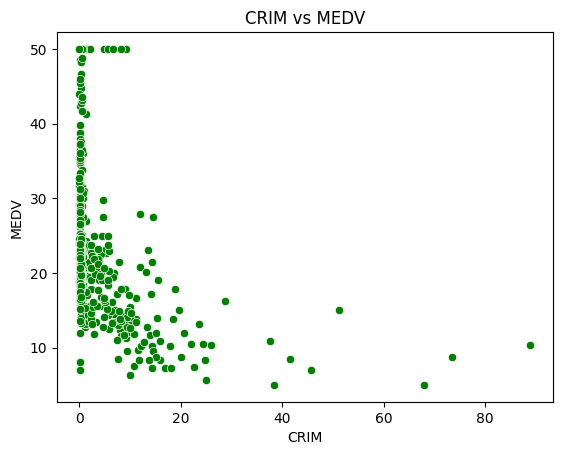

In [29]:
sns.scatterplot(x= 'CRIM', y= 'MEDV', data= mydata, color='green')
plt.title('CRIM vs MEDV')
plt.xlabel('CRIM')
plt.ylabel('MEDV')
plt.show()

In [32]:
### Barplots Average housing prices by accessibilty of Road Highways

rad_medv_mean = mydata.groupby("RAD")["MEDV"].mean()

print(rad_medv_mean)

RAD
1     24.365000
2     26.833333
3     27.928947
4     21.387273
5     25.706957
6     20.976923
7     27.105882
8     30.358333
24    16.403788
Name: MEDV, dtype: float64


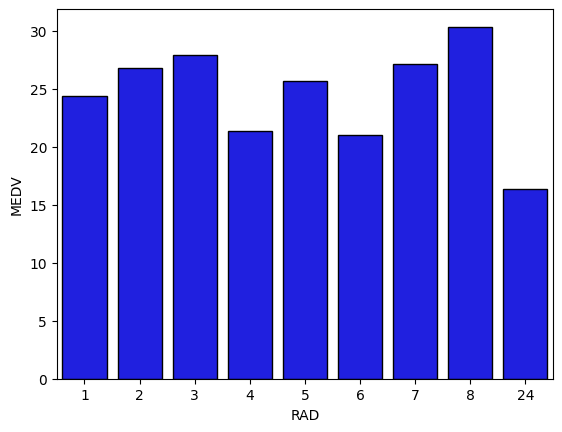

In [37]:
rad_medv_mean_df = rad_medv_mean.reset_index()
sns.barplot(x= "RAD", y= "MEDV", data= rad_medv_mean_df, color= "blue", edgecolor = "black")
plt.xlabel('RAD')
plt.ylabel('MEDV')
plt.show()

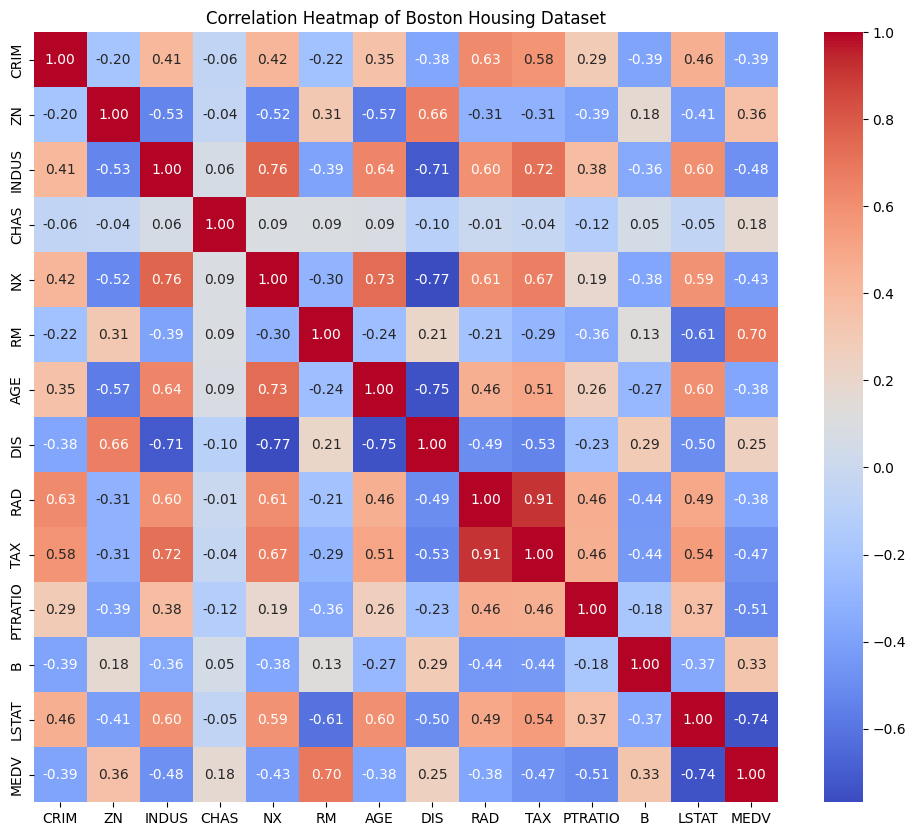

In [38]:
correlation_matrix = mydata.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Boston Housing Dataset')
plt.show()